# Patient Profile Creation

Install required packages

In [1]:
!pip install -q scikit-learn scipy

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import logging
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy import stats

In [3]:
# Configure paths
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1] / "1" / "Features"

# Feature file names
FILES_CONFIG = {
    'laboratory_tests': 'laboratory_tests_features.csv',
    'procedures': 'procedure_code_features.csv',
    'heart_diagnoses': 'heart_diagnoses_features.csv',
    'microbiology': 'microbiology_events_features.csv'
}

print(f"Feature Path: {FEATURE_PATH}")
print(f"Configuration loaded")

Feature Path: /home/gabriele/DAD/project/Tasks/1/Features
Configuration loaded


In [4]:
# Load all feature tables
dfs = {}
for key, filename in FILES_CONFIG.items():
    filepath = FEATURE_PATH / filename
    dfs[key] = pd.read_csv(filepath)

In [5]:
def identify_duplicates(dfs):
    """
    Identify dataframes with hadm_id associated to multiple subject_id.
    
    Args:
        dfs (dict): Dictionary of dataframes
        
    Returns:
        dict: Dictionary with problematic dataframe names and number of duplicate hadm_id
    """
    problematic_dfs = {}
    
    for name, df in dfs.items():
        if 'hadm_id' in df.columns and 'subject_id' in df.columns:
            hadm_id_counts = df.groupby('hadm_id')['subject_id'].nunique()
            multi_subject = hadm_id_counts[hadm_id_counts > 1]
            
            if len(multi_subject) > 0:
                problematic_dfs[name] = len(multi_subject)
    
    return problematic_dfs


In [6]:
def clean_duplicate_admissions(df, df_name):
    """
    Remove rows where the same hadm_id is associated to multiple subject_id.
    
    Args:
        df (pd.DataFrame): Dataframe to clean
        df_name (str): Dataframe name (for logging)
        
    Returns:
        pd.DataFrame: Cleaned dataframe
        int: Number of removed rows
    """
    original_shape = df.shape
    
    # Filter keeping only hadm_id with a single subject_id
    df_cleaned = df.groupby('hadm_id').filter(
        lambda x: x['subject_id'].nunique() == 1
    )
    
    rows_removed = len(df) - len(df_cleaned)
    
    return df_cleaned, rows_removed

In [7]:
def clean_all_dataframes(dfs):
    """
    Automatically clean all dataframes with duplicate issues.
    
    Args:
        dfs (dict): Dictionary of dataframes
        
    Returns:
        dict: Dictionary of cleaned dataframes
        dict: Cleaning statistics
    """
    
    cleaned_dfs = dfs.copy()
    cleaning_stats = {}
    
    for name, df in dfs.items():
        if 'hadm_id' in df.columns and 'subject_id' in df.columns:
            # Check if there are issues
            hadm_id_counts = df.groupby('hadm_id')['subject_id'].nunique()
            multi_subject = hadm_id_counts[hadm_id_counts > 1]
            
            if len(multi_subject) > 0:
                df_cleaned, rows_removed = clean_duplicate_admissions(df, name)
                cleaned_dfs[name] = df_cleaned
                cleaning_stats[name] = {
                    'rows_removed': rows_removed,
                    'original_shape': df.shape,
                    'cleaned_shape': df_cleaned.shape
                }
    
    return cleaned_dfs, cleaning_stats

In [8]:
def verify_cleaning(dfs):
    """
    Verify that all dataframes have been cleaned correctly.
    
    Args:
        dfs (dict): Dictionary of dataframes to verify
        
    Returns:
        bool: True if all dataframes are clean, False otherwise
    """
    all_clean = True
    
    for name, df in dfs.items():
        if 'hadm_id' in df.columns and 'subject_id' in df.columns:
            hadm_id_counts = df.groupby('hadm_id')['subject_id'].nunique()
            multi_subject = hadm_id_counts[hadm_id_counts > 1]
            
            is_clean = len(multi_subject) == 0
            
            if not is_clean:
                all_clean = False
    
    return all_clean


In [9]:
def process_dataframes(dfs):
    """
    Main function that orchestrates the entire cleaning process.
    
    Args:
        dfs (dict): Dictionary of dataframes to process
        
    Returns:
        dict: Dictionary of cleaned dataframes
        dict: Cleaning statistics
    """
    # 1. Identify problems
    problematic_dfs = identify_duplicates(dfs)
    
    if not problematic_dfs:
        return dfs, {}
    
    # 2. Clean dataframes
    cleaned_dfs, cleaning_stats = clean_all_dataframes(dfs)
    
    # 3. Verify cleaning
    all_clean = verify_cleaning(cleaned_dfs)
    
    # 4. Final summary
    if all_clean:
        for name, stats in cleaning_stats.items():
            print(f"  {name}: -{stats['rows_removed']} rows")
    
    return cleaned_dfs, cleaning_stats

In [10]:
dfs_cleaned, stats = process_dataframes(dfs)
dfs = dfs_cleaned

## Data Merging

In [11]:
print("\nHeart Diagnoses + Microbiology")

# Merge heart diagnoses with microbiology
heart_microbiology = pd.merge(
    dfs['heart_diagnoses'],
    dfs['microbiology'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('_heart', '_microbio')
)

print(f" Heart + Microbiology shape: {heart_microbiology.shape}")
print(f"   Unique patients: {heart_microbiology['subject_id'].nunique()}")


Heart Diagnoses + Microbiology
 Heart + Microbiology shape: (4711, 20)
   Unique patients: 4244


In [12]:
print("\nAdd Procedures")

# merge with procedures
heart_micro_procedures = pd.merge(
    heart_microbiology,
    dfs['procedures'],
    on=['subject_id', 'hadm_id'],
    how='outer',
    suffixes=('', '_proc')
)

print(f" Heart + Microbiology + Procedures shape: {heart_micro_procedures.shape}")
print(f"Unique patients: {heart_micro_procedures['subject_id'].nunique()}")


Add Procedures
 Heart + Microbiology + Procedures shape: (4746, 23)
Unique patients: 4278


In [13]:
# Merge with laboratory tests
patient_admissions = pd.merge(
    heart_micro_procedures,
    dfs['laboratory_tests'],
    on='hadm_id',
    how='outer',
    suffixes=('', '_lab')
)

patient_admissions['hadm_id'] = patient_admissions['hadm_id'].astype('Int64')

print(f"  Final merged shape: {patient_admissions.shape}")
print(f"  Unique patients: {patient_admissions['subject_id'].nunique()}")
print(f"  Total admissions: {patient_admissions['hadm_id'].nunique()}")

  Final merged shape: (4761, 35)
  Unique patients: 4278
  Total admissions: 4761


In [14]:
patient_admissions.drop_duplicates(
    subset=['subject_id', 'hadm_id'], 
    keep='first',
    inplace=True
)

print(f"  Final merged shape: {patient_admissions.shape}")
print(f"  Unique patients: {patient_admissions['subject_id'].nunique()}")
print(f"  Total admissions: {patient_admissions['hadm_id'].nunique()}")

  Final merged shape: (4761, 35)
  Unique patients: 4278
  Total admissions: 4761


In [15]:
# Conta quanti duplicati hai
n_duplicates = patient_admissions.duplicated(subset=['subject_id', 'hadm_id']).sum()
print(f"Numero di righe duplicate: {n_duplicates}")
# Dovrebbe essere: 5166 - 4761 = 405

# Visualizza esempi di duplicati
duplicated_mask = patient_admissions.duplicated(subset=['subject_id', 'hadm_id'], keep=False)
duplicated_examples = patient_admissions[duplicated_mask].sort_values(['subject_id', 'hadm_id'])
print(duplicated_examples[['subject_id', 'hadm_id']].head(10))


Numero di righe duplicate: 0
Empty DataFrame
Columns: [subject_id, hadm_id]
Index: []


In [16]:
patient_admissions.head()

,subject_id,hadm_id,age,gender,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,oxygen_saturation,...,tests_days_span,k_max,k_min,k_n,creat_max,creat_n,glu_max,glu_n,glu_var,na_cl_ratio
0,12869457.0,20004456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.0,...,2.0,5.6,4.8,3.0,2.7,3.0,193.0,3.0,36.94,1.33
1,13709807.0,20007905,NaN,NaN,NaN,135.0,62.0,127.0,29.0,93.0,...,3.0,4.8,4.1,7.0,1.3,7.0,314.0,6.0,29.85,1.40
2,12002285.0,20013519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.0,...,2.0,4.4,3.6,4.0,2.2,4.0,104.0,4.0,13.74,1.35
3,16110697.0,20013602,NaN,NaN,36.1,128.0,55.0,76.0,20.0,97.0,...,1.0,5.1,3.5,5.0,1.2,4.0,186.0,2.0,61.52,1.35
4,17171235.0,20014999,78.0,1.0,36.3,122.0,70.0,75.0,24.0,NaN,...,7.0,4.6,3.4,13.0,1.5,12.0,144.0,12.0,13.81,1.40


In [17]:
patient_admissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4761 entries, 0 to 4760
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     4746 non-null   float64
 1   hadm_id                        4761 non-null   Int64  
 2   age                            1326 non-null   float64
 3   gender                         1326 non-null   float64
 4   temperature                    2341 non-null   float64
 5   bp_systolic                    2295 non-null   float64
 6   bp_diastolic                   2295 non-null   float64
 7   heart_rate                     2165 non-null   float64
 8   respiratory_rate               2094 non-null   float64
 9   oxygen_saturation              3730 non-null   float64
 10  heart_failure_severity_score   1494 non-null   float64
 11  cad_severity_score             2422 non-null   float64
 12  valvular_disease_score         4103 non-null   f

In [18]:
patient_profiles = patient_admissions.copy()

## Data Quality Assessment

### Missingness analysis

In [19]:
patient_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4761 entries, 0 to 4760
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     4746 non-null   float64
 1   hadm_id                        4761 non-null   Int64  
 2   age                            1326 non-null   float64
 3   gender                         1326 non-null   float64
 4   temperature                    2341 non-null   float64
 5   bp_systolic                    2295 non-null   float64
 6   bp_diastolic                   2295 non-null   float64
 7   heart_rate                     2165 non-null   float64
 8   respiratory_rate               2094 non-null   float64
 9   oxygen_saturation              3730 non-null   float64
 10  heart_failure_severity_score   1494 non-null   float64
 11  cad_severity_score             2422 non-null   float64
 12  valvular_disease_score         4103 non-null   f

In [20]:
missing_stats = pd.DataFrame({
    'Feature': patient_profiles.columns,
    'Missing_Count': patient_profiles.isnull().sum(),
    'Missing_Pct': (patient_profiles.isnull().sum() / len(patient_profiles) * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

In [21]:
# Show top missing features
print("\nTop 15 features with missing data:")
print(missing_stats[missing_stats['Missing_Count'] > 0].head(15).to_string(index=False))


Top 15 features with missing data:
                     Feature  Missing_Count  Missing_Pct
                         age           3435        72.15
                      gender           3435        72.15
heart_failure_severity_score           3267        68.62
      ct_complications_score           3138        65.91
            respiratory_rate           2667        56.02
                  heart_rate           2596        54.53
    infection_severity_score           2563        53.83
                bp_diastolic           2466        51.80
                 bp_systolic           2466        51.80
                 temperature           2420        50.83
          cad_severity_score           2339        49.13
       ecg_abnormality_score           1624        34.11
           unique_procedures           1302        27.35
        procedures_days_span           1302        27.35
            total_procedures           1302        27.35


## 2. Identified Missingness Mechanisms

### MCAR - Administrative Error (not informative)
**Variables: Age, Gender**
- Identical 71.6% missing for both (always together)
- Perfect correlation (r=1.0) between the two patterns

### MAR/MNAR - Clinical Pattern (potentially informative)
**Variables: BP, Temperature, Heart Rate, Respiratory Rate**
- High co-missingness: BP-HR r=0.77, Temp-BP r=0.67
- 39.6% patients without ANY vital sign measurement
- Patients WITH vital signs have significantly higher severity:
  * Heart failure score: 2.32 vs 1.97 (p=0.001)
  * Respiratory distress: 1.19 vs 1.10
- Mechanism: vital signs measured preferentially in sicker patients

In [22]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional
from scipy.stats import ttest_ind, ks_2samp
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score


In [23]:
def compute_missing_statistics(df: pd.DataFrame, 
                               exclude_cols: List[str] = None) -> pd.DataFrame:
    """
    Compute comprehensive missing data statistics.
    
    Args:
        df: Input dataframe
        exclude_cols: Columns to exclude (e.g., IDs)
    
    Returns:
        DataFrame with missing statistics per feature
    """
    exclude_cols = exclude_cols or []
    
    def assign_category(pct):
        if pct == 0: return 'COMPLETE'
        elif pct < 5: return 'MINIMAL'
        elif pct < 20: return 'LOW'
        elif pct < 40: return 'MODERATE'
        elif pct < 60: return 'HIGH'
        else: return 'VERY_HIGH'
    
    missing_stats = pd.DataFrame({
        'Feature': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Pct': (df.isnull().sum() / len(df) * 100).round(2),
        'Dtype': df.dtypes
    })
    
    missing_stats['Category'] = missing_stats['Missing_Pct'].apply(assign_category)
    missing_stats = missing_stats[~missing_stats['Feature'].isin(exclude_cols)]
    missing_stats = missing_stats.sort_values('Missing_Pct', ascending=False)
    
    return missing_stats

In [24]:
def visualize_missingness_patterns(df: pd.DataFrame, 
                                   save_path: Optional[str] = None):
    """
    Visualize co-occurrence patterns of missing data.
    
    Args:
        df: Input dataframe
        save_path: Optional path to save figure
    """
    missing_matrix = df.isnull().astype(int)
    missing_corr = missing_matrix.corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(missing_corr, cmap='RdBu_r', center=0, 
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Correlation Between Missingness Patterns', fontsize=14)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()
    

In [25]:
def test_missingness_mechanism(df: pd.DataFrame, 
                               target_col: str,
                               predictor_cols: List[str]) -> pd.DataFrame:
    """
    Test whether missingness is MCAR, MAR, or MNAR using t-tests.
    
    Args:
        df: Input dataframe
        target_col: Column to test
        predictor_cols: Columns to use as predictors
    
    Returns:
        DataFrame with test results
    """
    results = []
    missing_indicator = df[target_col].isna()
    
    for pred in predictor_cols:
        if df[pred].dtype in ['float64', 'int64']:
            group_present = df[~missing_indicator][pred].dropna()
            group_missing = df[missing_indicator][pred].dropna()
            
            if len(group_present) > 0 and len(group_missing) > 0:
                t_stat, p_val = ttest_ind(group_present, group_missing)
                results.append({
                    'Predictor': pred,
                    'P_Value': p_val,
                    'Significant': p_val < 0.05,
                    'Mean_Present': group_present.mean(),
                    'Mean_Missing': group_missing.mean(),
                    'Mechanism': 'MAR/MNAR' if p_val < 0.05 else 'MCAR'
                })
    
    return pd.DataFrame(results)


In [26]:
test_results = test_missingness_mechanism(
    patient_profiles, 
    'temperature',
    ['heart_failure_severity_score', 'age', 'total_tests']
)

In [27]:
test_results

,Predictor,P_Value,Significant,Mean_Present,Mean_Missing,Mechanism
0,heart_failure_severity_score,0.010668,True,2.314085,2.044643,MAR/MNAR
1,age,0.633647,False,69.183775,68.789474,MCAR
2,total_tests,0.006771,True,154.994208,164.349380,MAR/MNAR


### Imputation 

In [28]:
def impute_with_knn(df: pd.DataFrame, 
                    features: List[str],
                    n_neighbors: int = 5) -> pd.DataFrame:
    """
    Impute features using KNN.
    
    Args:
        df: Input dataframe
        features: Features to impute
        n_neighbors: Number of neighbors for KNN
    
    Returns:
        Dataframe with imputed values
    """
    if not features:
        return df
    
    df_copy = df.copy()
    imputer = KNNImputer(n_neighbors=n_neighbors, weights='distance')
    df_copy[features] = imputer.fit_transform(df[features])
    
    return df_copy


def impute_with_mice(df: pd.DataFrame,
                     features: List[str],
                     max_iter: int = 10) -> pd.DataFrame:
    """
    Impute features using MICE (Iterative Imputer).
    
    Args:
        df: Input dataframe
        features: Features to impute
        max_iter: Maximum iterations
    
    Returns:
        Dataframe with imputed values
    """
    if not features:
        return df
    
    df_copy = df.copy()
    imputer = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=10, max_depth=10, random_state=42),
        max_iter=max_iter,
        random_state=42,
        verbose=0
    )
    df_copy[features] = imputer.fit_transform(df[features])
    
    return df_copy


def impute_demographics_with_rf(df: pd.DataFrame,
                                target_col: str,
                                exclude_cols: List[str] = None) -> pd.DataFrame:
    """
    Impute demographic variables (age/gender) using Random Forest.
    
    Args:
        df: Input dataframe
        target_col: Column to impute ('age' or 'gender')
        exclude_cols: Columns to exclude from predictors
    
    Returns:
        Dataframe with imputed demographics
    """
    exclude_cols = exclude_cols or []
    df_copy = df.copy()
    
    train_mask = df[target_col].notna()
    
    if train_mask.sum() < 10:
        # Insufficient data - use simple imputation
        fill_value = df[target_col].median() if df[target_col].dtype in ['float64', 'int64'] else df[target_col].mode()[0]
        df_copy[target_col].fillna(fill_value, inplace=True)
        return df_copy
    
    # Select predictive features
    pred_features = [col for col in df.select_dtypes(include=[np.number]).columns
                    if col not in [target_col, 'age', 'gender'] + exclude_cols
                    and not col.endswith('_missing')]
    
    if not pred_features:
        fill_value = df[target_col].median() if df[target_col].dtype in ['float64', 'int64'] else df[target_col].mode()[0]
        df_copy[target_col].fillna(fill_value, inplace=True)
        return df_copy
    
    # Fill missing in predictors with median
    for feat in pred_features:
        if df_copy[feat].isna().any():
            df_copy[feat].fillna(df_copy[feat].median(), inplace=True)
    
    # Prepare training data
    X_train = df_copy.loc[train_mask, pred_features]
    y_train = df_copy.loc[train_mask, target_col]
    X_test = df_copy.loc[~train_mask, pred_features]
    
    # Select and train model
    if target_col == 'gender' or df[target_col].nunique() < 10:
        model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    else:
        model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    df_copy.loc[~train_mask, target_col] = predictions
    
    return df_copy


In [29]:
def create_missingness_indicators(df: pd.DataFrame,
                                  features: List[str]) -> pd.DataFrame:
    """
    Create binary indicators for missing values.
    
    Args:
        df: Input dataframe
        features: Features to create indicators for
    
    Returns:
        Dataframe with added indicator columns
    """
    df_copy = df.copy()
    
    for feature in features:
        df_copy[f'{feature}_missing'] = df[feature].isna().astype(int)
    
    return df_copy


def multi_strategy_imputation(df: pd.DataFrame,
                              missing_stats: pd.DataFrame,
                              exclude_cols: List[str] = None,
                              verbose: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Apply multi-strategy imputation based on missingness level.
    
    Args:
        df: Input dataframe
        missing_stats: Missing statistics from compute_missing_statistics()
        exclude_cols: Columns to exclude
        verbose: Print progress
    
    Returns:
        Tuple of (imputed_df, imputation_summary)
    """
    exclude_cols = exclude_cols or []
    df_imputed = df.copy()
    imputation_log = []
    
    # Get features by category
    def get_features(category):
        return missing_stats[missing_stats['Category'] == category]['Feature'].tolist()
    
    # 1. LOW (5-20%): KNN
    low_missing = get_features('LOW')
    if low_missing:
        if verbose:
            print(f"\n[LOW] KNN Imputation: {len(low_missing)} features")
        df_imputed = impute_with_knn(df_imputed, low_missing, n_neighbors=5)
        imputation_log.extend([(f, 'KNN', 'LOW') for f in low_missing])
    
    # 2. MODERATE (20-40%): MICE
    moderate_missing = get_features('MODERATE')
    if moderate_missing:
        if verbose:
            print(f"[MODERATE] MICE Imputation: {len(moderate_missing)} features")
        df_imputed = impute_with_mice(df_imputed, moderate_missing, max_iter=10)
        imputation_log.extend([(f, 'MICE', 'MODERATE') for f in moderate_missing])
    
    # 3. HIGH (40-60%): Indicators + MICE
    high_missing = [f for f in get_features('HIGH') 
                   if 'score' in f.lower() or 'severity' in f.lower()]
    if high_missing:
        if verbose:
            print(f"[HIGH] Indicators + MICE: {len(high_missing)} features")
        df_imputed = create_missingness_indicators(df_imputed, high_missing)
        df_imputed = impute_with_mice(df_imputed, high_missing, max_iter=5)
        imputation_log.extend([(f, 'MICE+Indicator', 'HIGH') for f in high_missing])
    
    # 4. VERY HIGH (>60%): Predictive for demographics, Indicators for others
    very_high = get_features('VERY_HIGH')
    if very_high:
        if verbose:
            print(f"[VERY HIGH] Predictive/Indicators: {len(very_high)} features")
        
        for feature in very_high:
            # Create availability indicator
            df_imputed[f'{feature}_missing'] = (df[feature].isna()).astype(int)
            
            if feature in ['age', 'gender']:
                df_imputed = impute_demographics_with_rf(df_imputed, feature, exclude_cols)
                imputation_log.append((feature, 'RF_Predictive', 'VERY_HIGH'))
            else:
                #Median/mode
                if df[feature].dtype in ['float64', 'int64']:
                    df_imputed[feature].fillna(df[feature].median(), inplace=True)
                else:
                    df_imputed[feature].fillna(df[feature].mode()[0], inplace=True)
                imputation_log.append((feature, 'Median+Indicator', 'VERY_HIGH'))
    
    # Create summary
    imputation_summary = pd.DataFrame(
        imputation_log,
        columns=['Feature', 'Method', 'Category']
    )
    
    return df_imputed, imputation_summary


### Validation and feature selection

In [30]:
def validate_imputation_visual(original_df: pd.DataFrame,
                               imputed_df: pd.DataFrame,
                               features: List[str],
                               save_path: Optional[str] = None):
    """
    Visual validation of imputation quality.
    
    Args:
        original_df: Original dataframe with missing values
        imputed_df: Imputed dataframe
        features: Features to validate
        save_path: Optional path to save figure
    """
    n_features = len(features)
    fig, axes = plt.subplots(n_features, 2, figsize=(14, 5*n_features))
    
    if n_features == 1:
        axes = axes.reshape(1, -1)
    
    for idx, feature in enumerate(features):
        # Histogram
        ax1 = axes[idx, 0]
        original_df[feature].dropna().hist(bins=30, alpha=0.6, label='Original', 
                                           ax=ax1, color='blue')
        imputed_df[feature].hist(bins=30, alpha=0.6, label='Imputed', 
                                ax=ax1, color='red')
        ax1.legend()
        ax1.set_title(f'{feature} - Distribution')
        ax1.set_xlabel('Value')
        ax1.set_ylabel('Frequency')
        
        # Boxplot
        ax2 = axes[idx, 1]
        bp = ax2.boxplot([original_df[feature].dropna(), imputed_df[feature]],
                        labels=['Original', 'Imputed'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax2.set_title(f'{feature} - Boxplot')
        ax2.set_ylabel('Value')
        ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def validate_imputation_statistical(original_df: pd.DataFrame,
                                    imputed_df: pd.DataFrame,
                                    features: List[str]) -> pd.DataFrame:
    """
    Statistical validation using Kolmogorov-Smirnov test.
    
    Args:
        original_df: Original dataframe
        imputed_df: Imputed dataframe
        features: Features to validate
    
    Returns:
        DataFrame with validation results
    """
    results = []
    
    for feature in features:
        original_data = original_df[feature].dropna()
        imputed_only = imputed_df.loc[original_df[feature].isna(), feature]
        
        if len(imputed_only) > 0:
            statistic, p_value = ks_2samp(original_data, imputed_only)
            
            results.append({
                'Feature': feature,
                'N_Imputed': len(imputed_only),
                'KS_Statistic': statistic,
                'P_Value': p_value,
                'Similar_Distribution': p_value > 0.05,
                'Original_Mean': original_data.mean(),
                'Imputed_Mean': imputed_only.mean()
            })
    
    return pd.DataFrame(results)

def create_composite_features(df: pd.DataFrame,
                              original_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create engineered features based on missingness patterns.
    
    Args:
        df: Imputed dataframe
        original_df: Original dataframe with missing values
    
    Returns:
        Enhanced dataframe
    """
    df_enhanced = df.copy()
    
    # Data completeness score
    df_enhanced['data_completeness_score'] = (
        original_df.notna().sum(axis=1) / original_df.shape[1]
    )
    
    # Composite severity
    severity_cols = [col for col in df.columns 
                    if 'severity' in col.lower() or 'score' in col.lower()]
    if severity_cols:
        df_enhanced['composite_severity'] = df[severity_cols].mean(axis=1, skipna=True)
    
    # Monitoring intensity
    vital_measured_cols = [col for col in df.columns if '_measured' in col]
    if vital_measured_cols:
        df_enhanced['monitoring_intensity'] = df[vital_measured_cols].sum(axis=1)
    
    # High missing flag
    df_enhanced['high_missing_patient'] = (
        df_enhanced['data_completeness_score'] < 0.5
    ).astype(int)
    
    return df_enhanced

                                                   Feature  Missing_Count  \
age                                                    age           3435   
gender                                              gender           3435   
heart_failure_severity_score  heart_failure_severity_score           3267   
ct_complications_score              ct_complications_score           3138   
respiratory_rate                          respiratory_rate           2667   
heart_rate                                      heart_rate           2596   
infection_severity_score          infection_severity_score           2563   
bp_diastolic                                  bp_diastolic           2466   
bp_systolic                                    bp_systolic           2466   
temperature                                    temperature           2420   

                              Missing_Pct    Dtype   Category  
age                                 72.15  float64  VERY_HIGH  
gender                  

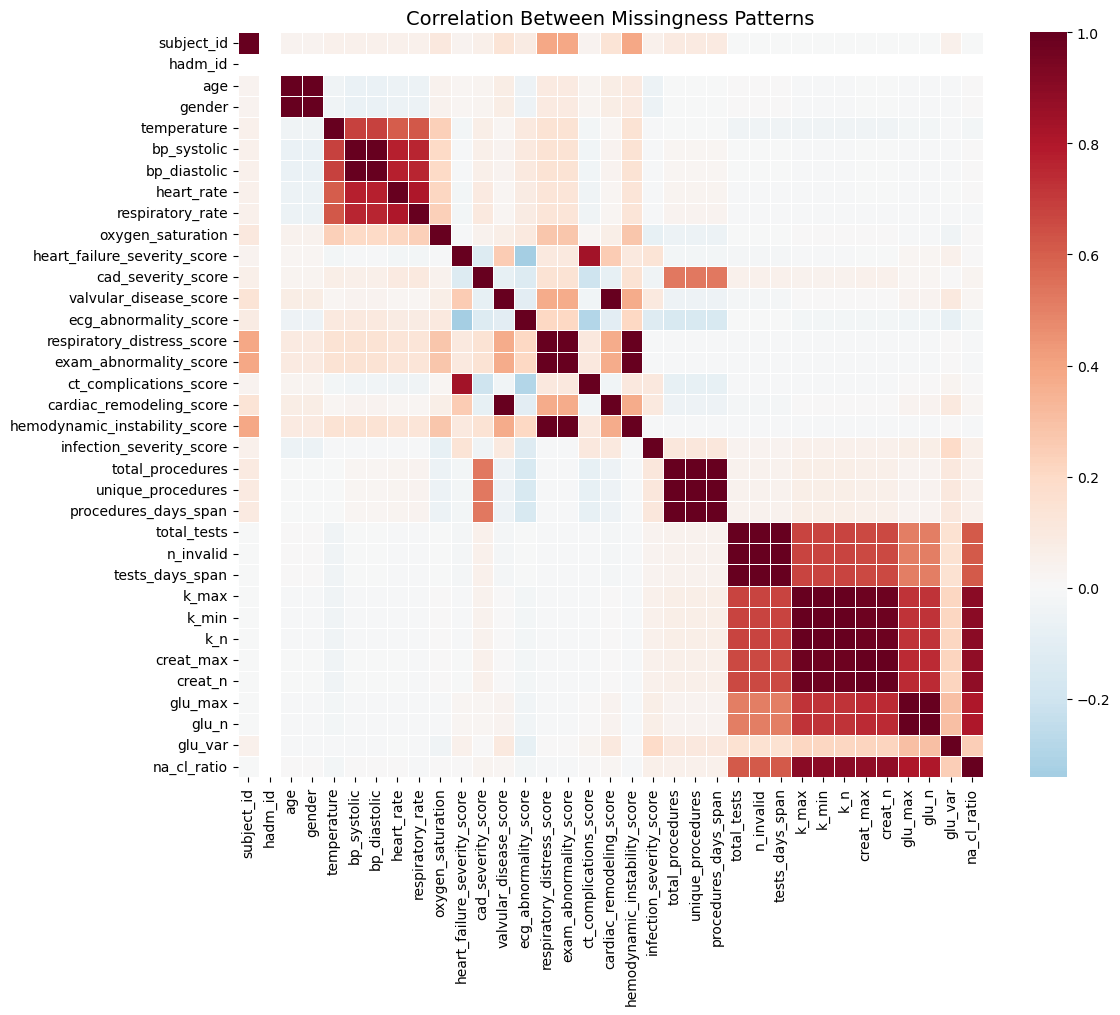

In [31]:
missing_stats = compute_missing_statistics(patient_profiles, ['subject_id', 'hadm_id'])
print(missing_stats.head(10))

visualize_missingness_patterns(patient_profiles)


In [32]:
df_imputed, summary = multi_strategy_imputation(
    patient_profiles, missing_stats, ['subject_id', 'hadm_id']
)


[LOW] KNN Imputation: 3 features
[MODERATE] MICE Imputation: 5 features


/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/tmp/ipykernel_49745/199690868.py:92: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy[feat].fillna(df_copy[feat].median(), inplace=True)


[HIGH] Indicators + MICE: 2 features
[VERY HIGH] Predictive/Indicators: 4 features


/tmp/ipykernel_49745/477420571.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[feature].fillna(df[feature].median(), inplace=True)
/tmp/ipykernel_49745/477420571.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

/tmp/ipykernel_49745/729276819.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([original_df[feature].dropna(), imputed_df[feature]],
/tmp/ipykernel_49745/729276819.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([original_df[feature].dropna(), imputed_df[feature]],


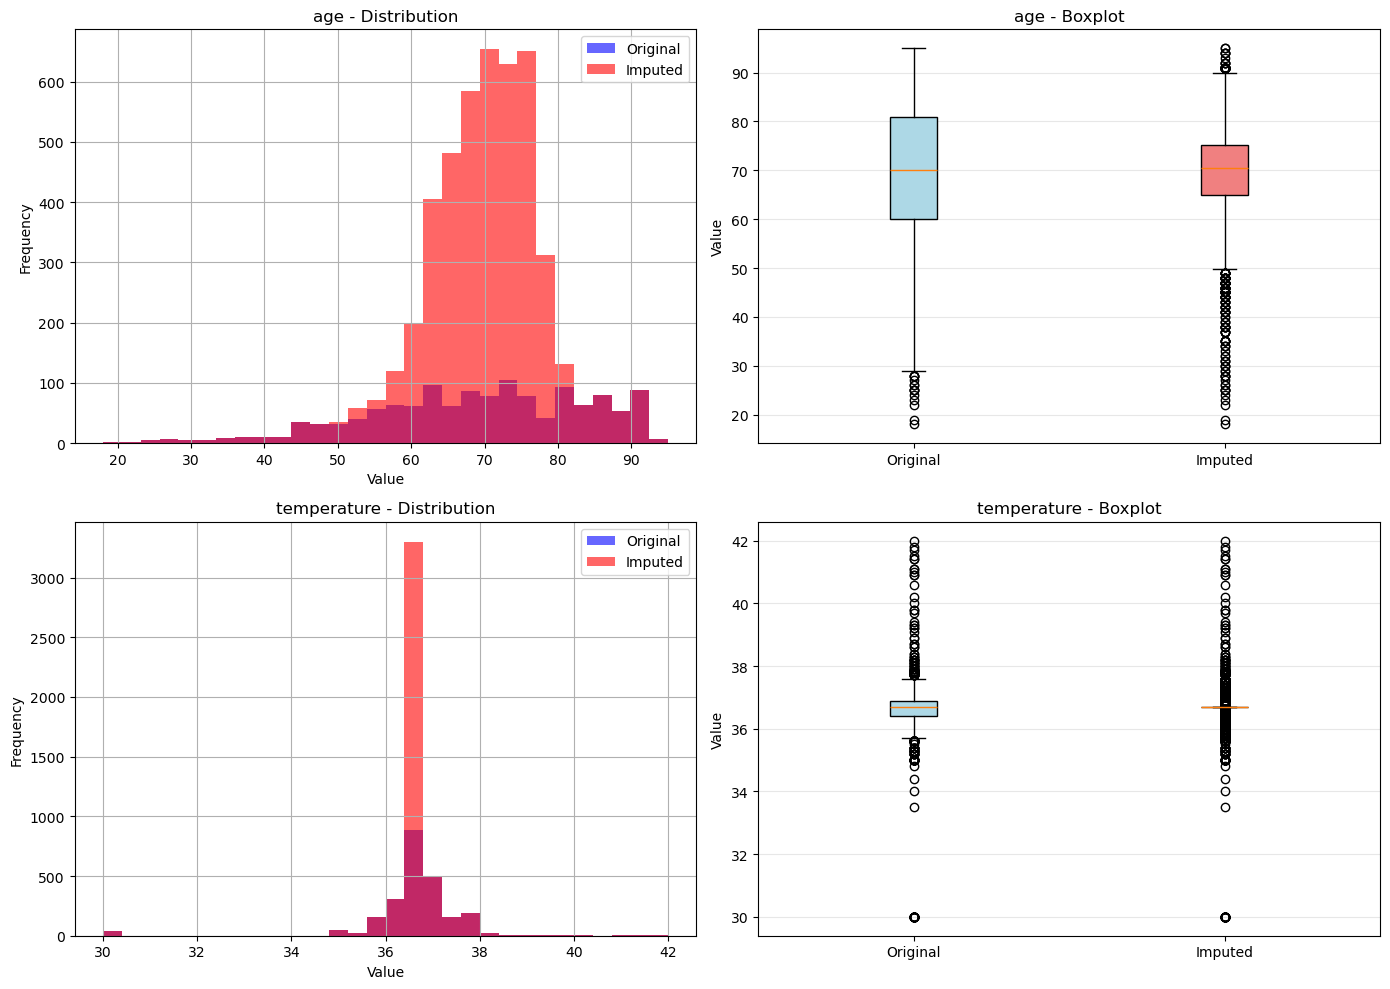

In [33]:
validate_imputation_visual(patient_profiles, df_imputed, ['age', 'temperature'])

In [34]:
patient_profiles = df_imputed.copy()

In [35]:
patient_profiles.columns

Index(['subject_id', 'hadm_id', 'age', 'gender', 'temperature', 'bp_systolic',
       'bp_diastolic', 'heart_rate', 'respiratory_rate', 'oxygen_saturation',
       'heart_failure_severity_score', 'cad_severity_score',
       'valvular_disease_score', 'ecg_abnormality_score',
       'respiratory_distress_score', 'exam_abnormality_score',
       'ct_complications_score', 'cardiac_remodeling_score',
       'hemodynamic_instability_score', 'infection_severity_score',
       'total_procedures', 'unique_procedures', 'procedures_days_span',
       'total_tests', 'n_invalid', 'tests_days_span', 'k_max', 'k_min', 'k_n',
       'creat_max', 'creat_n', 'glu_max', 'glu_n', 'glu_var', 'na_cl_ratio',
       'infection_severity_score_missing', 'cad_severity_score_missing',
       'age_missing', 'gender_missing', 'heart_failure_severity_score_missing',
       'ct_complications_score_missing'],
      dtype='object')

## Feature engeneering

In [36]:
def create_comprehensive_patient_profile(
    df_imputed: pd.DataFrame,
    exclude_cols: List[str] = None,
    keep_original_features: bool = False,
) -> pd.DataFrame:
    """
    Create a comprehensive patient profile with clinical + derived features.
    REMOVES original features that were aggregated into composite scores.

    Args:
        df_imputed: Imputed dataframe
        df_original: Original dataframe with missing values
        exclude_cols: Columns to exclude
        keep_original_features: If True, keeps both scores AND original features
                               (useful for debugging, but NOT recommended for clustering)

    Returns:
        Enhanced patient profile dataframe
    """
    exclude_cols = exclude_cols or []
    df = df_imputed.copy()

    # Track features to potentially remove
    features_to_remove = []

    severity_cols = [
        "heart_failure_severity_score",
        "cad_severity_score",
        "valvular_disease_score",
        "respiratory_distress_score",
        "infection_severity_score",
        "hemodynamic_instability_score",
    ]

    available_severity = [c for c in severity_cols if c in df.columns]

    if available_severity:
        weights = {
            "heart_failure_severity_score": 1.5,
            "cad_severity_score": 1.3,
            "hemodynamic_instability_score": 1.4,
            "valvular_disease_score": 1.0,
            "respiratory_distress_score": 1.2,
            "infection_severity_score": 1.1,
        }

        df["disease_burden_score"] = 0
        total_weight = 0

        for col in available_severity:
            weight = weights.get(col, 1.0)
            df["disease_burden_score"] += df[col] * weight
            total_weight += weight

        df["disease_burden_score"] /= total_weight

        if not keep_original_features:
            features_to_remove.extend(available_severity)

    vital_cols = ["bp_systolic", "bp_diastolic", "heart_rate", "temperature"]

    if all(c in df.columns for c in vital_cols):
        df["bp_systolic_norm"] = (df["bp_systolic"] - 90) / (180 - 90)
        df["heart_rate_norm"] = (df["heart_rate"] - 40) / (150 - 40)
        df["temp_norm"] = (df["temperature"] - 35) / (40 - 35)

        df["hemodynamic_stability_index"] = (
            1
            - (
                abs(df["bp_systolic_norm"] - 0.5)
                + abs(df["heart_rate_norm"] - 0.5)
                + abs(df["temp_norm"] - 0.5)
            )
            / 3
        )

        df.drop(
            [
                "bp_systolic_norm",
                "heart_rate_norm",
                "temp_norm",
                "heart_failure_severity_score",
                "cad_severity_score",
                "valvular_disease_score",
                "respiratory_distress_score",
                "infection_severity_score",
                "hemodynamic_instability_score",
            ],
            axis=1,
            inplace=True,
        )

        if not keep_original_features:
            if "bp_diastolic" in df.columns:
                features_to_remove.append("bp_diastolic")

    if "creat_max" in df.columns:

        def categorize_renal_function(creat):
            if creat < 1.2:
                return 0  # Normal
            elif creat < 2.0:
                return 1  # Mild
            elif creat < 3.5:
                return 2  # Moderate
            else:
                return 3  # Severe

        df["renal_function_category"] = df["creat_max"].apply(categorize_renal_function)

        if not keep_original_features:
            if "creat_n" in df.columns:
                features_to_remove.append("creat_n")

    if "glu_var" in df.columns and "glu_max" in df.columns:
        df["glu_var_norm"] = (df["glu_var"] - df["glu_var"].min()) / (
            df["glu_var"].max() - df["glu_var"].min()
        )
        df["glu_max_norm"] = (df["glu_max"] - 70) / (300 - 70)

        df["metabolic_dysregulation"] = (
            df["glu_var_norm"] * 0.6 + df["glu_max_norm"] * 0.4
        )

        # Clean up temporary columns
        df.drop(["glu_var_norm", "glu_max_norm"], axis=1, inplace=True)

        # MARK FOR REMOVAL: Both glu_var and glu_max (info captured in composite)
        if not keep_original_features:
            features_to_remove.extend(["glu_var", "glu_max"])

            # Also remove glu_n (redundant count)
            if "glu_n" in df.columns:
                features_to_remove.append("glu_n")

    if "total_procedures" in df.columns and "procedures_days_span" in df.columns:
        df["procedure_complexity"] = df["total_procedures"] / (
            df["procedures_days_span"] + 1
        )
        df["procedure_complexity"] = df["procedure_complexity"].clip(
            upper=df["procedure_complexity"].quantile(0.99)
        )

        if not keep_original_features:
            features_to_remove.append("procedures_days_span")

    if "total_tests" in df.columns and "tests_days_span" in df.columns:
        df["testing_intensity"] = df["total_tests"] / (df["tests_days_span"] + 1)
        df["testing_intensity"] = df["testing_intensity"].clip(
            upper=df["testing_intensity"].quantile(0.99)
        )

        if not keep_original_features:
            features_to_remove.append("tests_days_span")

    span_cols = [c for c in df.columns if "days_span" in c]

    if span_cols:
        df["total_engagement_days"] = df[span_cols].max(axis=1)

        if not keep_original_features:
            features_to_remove.extend(span_cols)

    if "vital_monitoring_level" in df.columns and "disease_burden_score" in df.columns:
        df["monitoring_severity_interaction"] = (
            df["vital_monitoring_level"] * df["disease_burden_score"]
        )

    # High-risk patient
    risk_criteria = []

    if "age" in df.columns:
        risk_criteria.append(df["age"] > 75)

    if "disease_burden_score" in df.columns:
        risk_criteria.append(
            df["disease_burden_score"] > df["disease_burden_score"].quantile(0.75)
        )

    if "renal_function_category" in df.columns:
        risk_criteria.append(df["renal_function_category"] >= 2)

    if risk_criteria:
        df["high_risk_patient"] = sum(risk_criteria).astype(int)

    # Frailty indicator
    if all(
        c in df.columns for c in ["age", "vital_monitoring_level", "total_procedures"]
    ):
        df["frailty_indicator"] = (
            (df["age"] > 70)
            & (df["vital_monitoring_level"] <= 1)
            & (df["total_procedures"] < df["total_procedures"].quantile(0.25))
        ).astype(int)

    # Complex patient
    complexity_features = []
    if "disease_burden_score" in df.columns:
        complexity_features.append(
            df["disease_burden_score"] > df["disease_burden_score"].quantile(0.75)
        )
    if "procedure_complexity" in df.columns:
        complexity_features.append(
            df["procedure_complexity"] > df["procedure_complexity"].quantile(0.75)
        )
    if "testing_intensity" in df.columns:
        complexity_features.append(
            df["testing_intensity"] > df["testing_intensity"].quantile(0.75)
        )

    if complexity_features:
        df["complex_patient"] = sum(complexity_features).astype(int)

    if not keep_original_features and features_to_remove:
        # Deduplicate list
        features_to_remove = list(set(features_to_remove))

        # Only remove features that actually exist in dataframe
        features_to_remove = [f for f in features_to_remove if f in df.columns]

        df.drop(columns=features_to_remove, inplace=True)

    engineered_features = [
        "disease_burden_score",
        "hemodynamic_stability_index",
        "renal_function_category",
        "metabolic_dysregulation",
        "procedure_complexity",
        "testing_intensity",
        "total_engagement_days",
        "monitoring_severity_interaction",
        "high_risk_patient",
        "frailty_indicator",
        "complex_patient",
    ]

    created_features = [f for f in engineered_features if f in df.columns]

    for feat in created_features:
        print(f"  • {feat}")

    print(f"\n📊 Final dataset:")
    print(f"  • Total columns: {len(df.columns)}")
    print(f"  • Total rows: {len(df)}")

    if not keep_original_features:
        print(f"  • Redundant features removed: {len(features_to_remove)}")

    return df

In [37]:
patient_profiles = create_comprehensive_patient_profile(df_imputed)

  • disease_burden_score
  • hemodynamic_stability_index
  • renal_function_category
  • metabolic_dysregulation
  • procedure_complexity
  • testing_intensity
  • total_engagement_days
  • high_risk_patient
  • complex_patient

📊 Final dataset:
  • Total columns: 37
  • Total rows: 4761
  • Redundant features removed: 7


## Dimensionality Reduction

In [38]:
numeric_cols = patient_profiles.select_dtypes(include='number').columns
features_cols = [col for col in numeric_cols if col not in ['subject_id', 'hadm_id']]

In [39]:
# Create working dataframe
X = patient_profiles[features_cols].copy()

In [40]:
X.columns

Index(['age', 'gender', 'temperature', 'bp_systolic', 'heart_rate',
       'respiratory_rate', 'oxygen_saturation', 'ecg_abnormality_score',
       'exam_abnormality_score', 'ct_complications_score',
       'cardiac_remodeling_score', 'total_procedures', 'unique_procedures',
       'total_tests', 'n_invalid', 'k_max', 'k_min', 'k_n', 'creat_max',
       'na_cl_ratio', 'infection_severity_score_missing',
       'cad_severity_score_missing', 'age_missing', 'gender_missing',
       'heart_failure_severity_score_missing',
       'ct_complications_score_missing', 'disease_burden_score',
       'hemodynamic_stability_index', 'renal_function_category',
       'metabolic_dysregulation', 'procedure_complexity', 'testing_intensity',
       'total_engagement_days', 'high_risk_patient', 'complex_patient'],
      dtype='object')

In [41]:
# Identify missingness indicators to PROTECT
missingness_indicators = [col for col in X.columns 
                          if '_measured' in col 
                          or col == 'num_vitals_measured' 
                          or col == 'has_vital_monitoring']

for mi in missingness_indicators:
    print(f"   - {mi}")

In [42]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.01)
sel.fit(X)
variance_passed = X.columns[sel.get_support()].tolist()
features_to_keep = list(set(variance_passed + missingness_indicators))

print(f"Before variance filter: {X.shape[1]} features")
X = X[features_to_keep]
print(f"After variance filter: {X.shape[1]} features")


Before variance filter: 35 features
After variance filter: 33 features


In [43]:
import numpy as np
corr_matrix = X.corr()
print(f"Correlation matrix: {corr_matrix.shape}")

Correlation matrix: (33, 33)


In [44]:
# Find High correlation feature pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append({
                    'feature_1': corr_matrix.columns[i],
                    'feature_2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)

In [45]:
high_corr = find_high_correlations(corr_matrix, threshold=0.8)
print(high_corr)

                        feature_1                             feature_2  \
1                     age_missing                        gender_missing   
0               unique_procedures                      total_procedures   
4                             k_n                           total_tests   
6                       n_invalid                           total_tests   
5                             k_n                 total_engagement_days   
8                     total_tests                 total_engagement_days   
2                       creat_max               renal_function_category   
3                             k_n                             n_invalid   
7                       n_invalid                 total_engagement_days   
9  ct_complications_score_missing  heart_failure_severity_score_missing   

   correlation  
1     1.000000  
0     0.985620  
4     0.952324  
6     0.947929  
5     0.935894  
8     0.929199  
2     0.914339  
3     0.905566  
7     0.869769  
9   

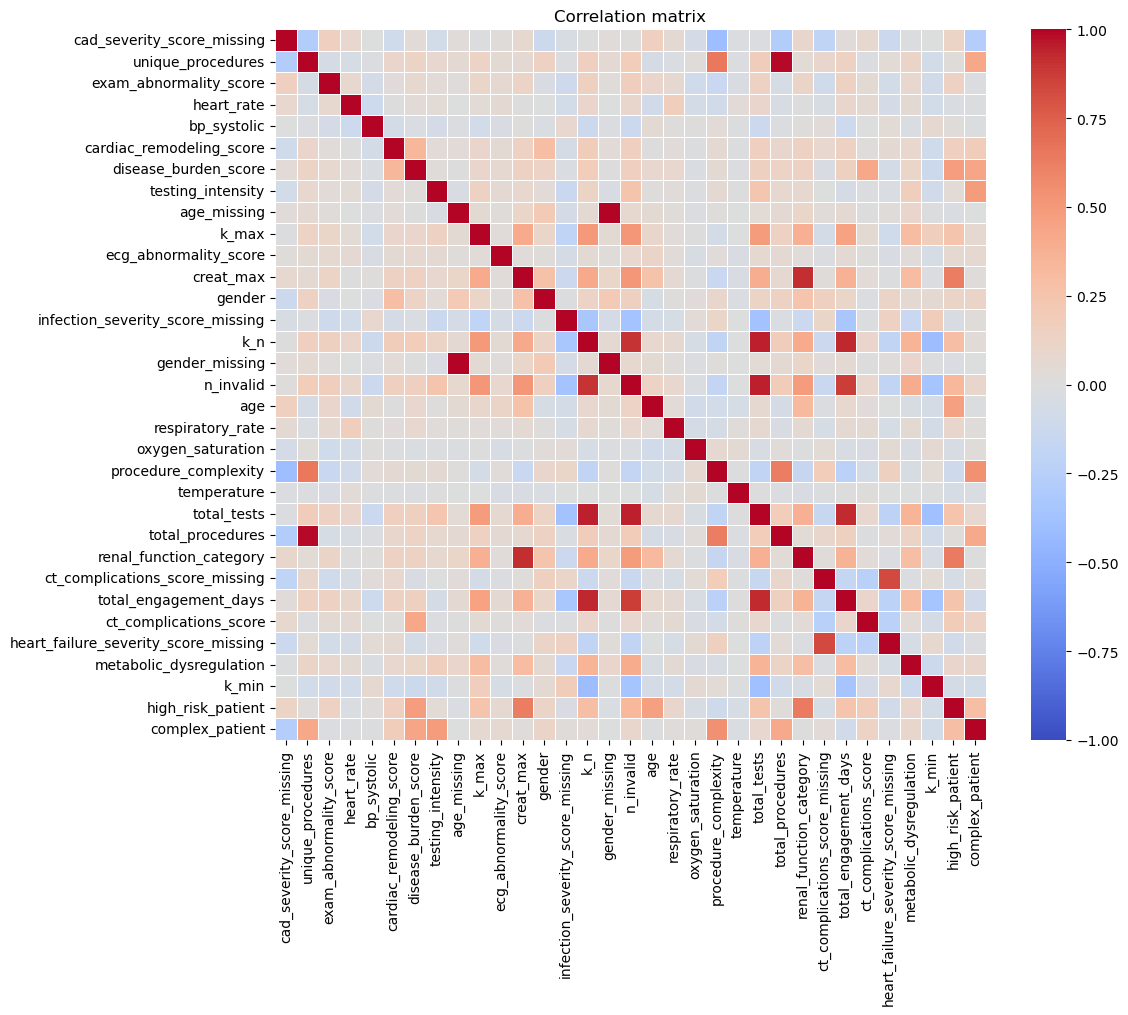

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap base
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=False,  
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()


As we can see, there are lot of redundant features, so we have to choose which ones to keep and which ones to discard.

In [47]:
high_corr = find_high_correlations(corr_matrix, threshold=0.80)
print(f"Highly correlated pairs found (r > 0.80): {len(high_corr)}")

Highly correlated pairs found (r > 0.80): 10


In [48]:
from collections import defaultdict

# protect missingness indicators
protected_features = [col for col in X.columns 
                     if '_measured' in col or col == 'num_vitals_measured' 
                     or col == 'has_vital_monitoring']

corr_groups = defaultdict(set)
for feat1, feat2, corr_val in high_corr.itertuples(index=False):
    group_key = min(feat1, feat2)
    corr_groups[group_key].add(feat1)
    corr_groups[group_key].add(feat2)

features_to_remove = set()

for group_key, group_features in corr_groups.items():
    if len(group_features) <= 1:
        continue
    
    # Check if any protected features in this group
    protected_in_group = [f for f in group_features if f in protected_features]
    
    if protected_in_group:
        # KEEP protected, remove others
        features_to_remove.update([f for f in group_features if f not in protected_features])
    else:
        # Normal behavior: keep highest variance
        variances = {feat: X[feat].var() for feat in group_features if feat in X.columns}
        sorted_by_var = sorted(variances.items(), key=lambda x: x[1], reverse=True)
        keep_feature = sorted_by_var[0][0]
        remove_features = [f for f, _ in sorted_by_var[1:]]
        
        features_to_remove.update(remove_features)
        
        for feat, var in sorted_by_var:
            status = "KEEP" if feat == keep_feature else "REMOVE"
            print(f"   {status:7} {feat:40} (var={var:.3f})")

print(f"Features to remove: {len(features_to_remove)}")
print(f"Final features: {X.shape[1] - len(features_to_remove)}")

# Verify protected features are NOT being removed
removed_protected = [f for f in features_to_remove if f in protected_features]
if removed_protected:
    features_to_remove = features_to_remove - set(removed_protected)

X = X.drop(columns=list(features_to_remove), errors='ignore')


   KEEP    gender_missing                           (var=0.201)
   REMOVE  age_missing                              (var=0.201)
   KEEP    total_procedures                         (var=5.519)
   REMOVE  unique_procedures                        (var=5.024)
   KEEP    total_tests                              (var=14151.861)
   REMOVE  n_invalid                                (var=2668.098)
   REMOVE  k_n                                      (var=29.924)
   REMOVE  total_engagement_days                    (var=12.818)
   KEEP    total_tests                              (var=14151.861)
   REMOVE  n_invalid                                (var=2668.098)
   REMOVE  total_engagement_days                    (var=12.818)
   KEEP    total_tests                              (var=14151.861)
   REMOVE  total_engagement_days                    (var=12.818)
   KEEP    renal_function_category                  (var=0.605)
   REMOVE  creat_max                                (var=0.511)
   KEEP    ct_comp

In [49]:
final_features = X.columns.tolist()
patient_profiles_clean = patient_profiles[final_features].copy()

In [50]:
missing_counts = patient_profiles_clean.isna().sum()
missing_pct = (missing_counts / len(patient_profiles_clean) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Pct': missing_pct.values
}).sort_values('Missing_Pct', ascending=False)

In [51]:
missing_df[missing_df['Missing_Pct'] > 0].shape

(0, 3)

In [52]:
missing_df[missing_df['Missing_Pct'] > 0].head(15)

,Feature,Missing_Count,Missing_Pct


In [53]:
patient_profiles_clean.columns

Index(['cad_severity_score_missing', 'exam_abnormality_score', 'heart_rate',
       'bp_systolic', 'cardiac_remodeling_score', 'disease_burden_score',
       'testing_intensity', 'k_max', 'ecg_abnormality_score', 'gender',
       'infection_severity_score_missing', 'gender_missing', 'age',
       'respiratory_rate', 'oxygen_saturation', 'procedure_complexity',
       'temperature', 'total_tests', 'total_procedures',
       'renal_function_category', 'ct_complications_score_missing',
       'ct_complications_score', 'metabolic_dysregulation', 'k_min',
       'high_risk_patient', 'complex_patient'],
      dtype='object')

## Final dataset statistics

In [54]:
# === FINAL FEATURE SET VERIFICATION ===
print("\n" + "="*70)
print("FINAL CLUSTERING FEATURES - VERIFICATION")
print("="*70)

# Check missingness indicators
missingness_features = [col for col in X.columns 
                       if '_measured' in col or col == 'num_vitals_measured' 
                       or col == 'has_vital_monitoring']

# Check corresponding vital signs
vital_base_names = ['temperature', 'bp_systolic', 'bp_diastolic', 
                    'heart_rate', 'respiratory_rate', 'oxygen_saturation']

vital_values = [col for col in X.columns if any(v in col for v in vital_base_names)
                and '_measured' not in col]

print(f"\n VITAL SIGNS VALUES ({len(vital_values)} features):")
for v in sorted(vital_values):
    print(f"   • {v}")

print(f"\n MISSINGNESS INDICATORS ({len(missingness_features)} features) [INFORMATIVE]:")
for m in sorted(missingness_features):
    n_missing = (patient_profiles[m] == 1).sum() if m in patient_profiles.columns else 'N/A'
    print(f"   • {m:35} (flag=1 for {n_missing} patients)")

print(f"\n OTHER FEATURES ({len(X.columns) - len(vital_values) - len(missingness_features)} features):")
other_features = [col for col in X.columns 
                  if col not in vital_values and col not in missingness_features]
for o in sorted(other_features)[:10]:
    print(f"   • {o}")
if len(other_features) > 10:
    print(f"   ... and {len(other_features)-10} more")

print(f"\n{'='*70}")
print(f" TOTAL FEATURES FOR CLUSTERING: {X.shape[1]}")
print(f"  - {len(vital_values)} imputed vital sign values")
print(f"  - {len(missingness_features)} missingness indicators (clinical monitoring level)")
print(f"  - {len(other_features)} other clinical/lab features")
print(f"{'='*70}\n")

# Verify strategy
if len(missingness_features) > 0:
    print(" Strategy implemented correctly:")
    print("  • Vital signs: imputed values capture physiological state")
    print("  • Missingness flags: capture intensity of clinical monitoring")
    print("  • Both types will be used for clustering")
else:
    print(" WARNING: No missingness indicators found!")
    print("   Check if they were accidentally removed during feature selection")



FINAL CLUSTERING FEATURES - VERIFICATION

 VITAL SIGNS VALUES (5 features):
   • bp_systolic
   • heart_rate
   • oxygen_saturation
   • respiratory_rate
   • temperature

 MISSINGNESS INDICATORS (0 features) [INFORMATIVE]:

 OTHER FEATURES (21 features):
   • age
   • cad_severity_score_missing
   • cardiac_remodeling_score
   • complex_patient
   • ct_complications_score
   • ct_complications_score_missing
   • disease_burden_score
   • ecg_abnormality_score
   • exam_abnormality_score
   • gender
   ... and 11 more

 TOTAL FEATURES FOR CLUSTERING: 26
  - 5 imputed vital sign values
  - 0 missingness indicators (clinical monitoring level)
  - 21 other clinical/lab features

   Check if they were accidentally removed during feature selection


### patient-wise features transformation

Before applying the transformations to the final patient-wise variables, we need to analyze their distribution to better understand what type of trasnformation they need.

We divide the features we have for clinical purposes: 


In [55]:
feature_groups = {
    "Demographics": [
        "age", 
        "gender"
    ],
    
    "Clinical Severity - Composite": [
        "disease_burden_score",  
    ],
    
    "Vital Signs": [
        "temperature",
        "heart_rate",
        "respiratory_rate",
        "oxygen_saturation",
        "bp_systolic",
    ],
    
    "Lab Values - Electrolytes": [
        "k_min",
        "k_max",
    ],
    
    "Lab Values - Metabolic": [
        "metabolic_dysregulation",  
    ],
    
    "Lab Values - Renal Function": [
        "renal_function_category",  
    ],
    
    "Healthcare Utilization - Procedures": [
        "total_procedures",
        "procedure_complexity",  
    ],
    
    "Healthcare Utilization - Testing": [
        "total_tests",
        "testing_intensity",  
    ],
    
    "Risk Indicators": [
        "high_risk_patient",  
        "complex_patient",    
    ],
    
    "Missingness Indicators": [
        "gender_missing",
        "cad_severity_score_missing",
        "ct_complications_score_missing",
        "infection_severity_score_missing",
    ],
}


Now we can visualize the distributions of the clinical features groups

/tmp/ipykernel_49745/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


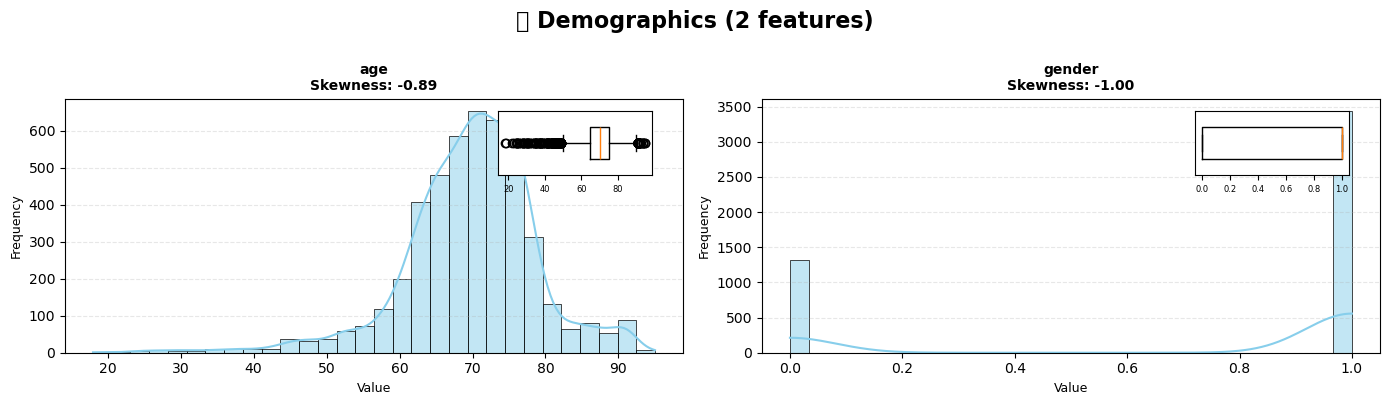

/tmp/ipykernel_49745/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



Group: Demographics

age:
  • N values: 4761
  • Range: [18.00, 95.00]
  • Mean: 69.77 ± 9.19
  • Median: 70.47
  • Skewness: -0.89
  • % NaN: 0.0%

gender:
  • N values: 4761
  • Range: [0.00, 1.00]
  • Mean: 0.72 ± 0.45
  • Median: 1.00
  • Skewness: -1.00
  • % NaN: 0.0%




/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


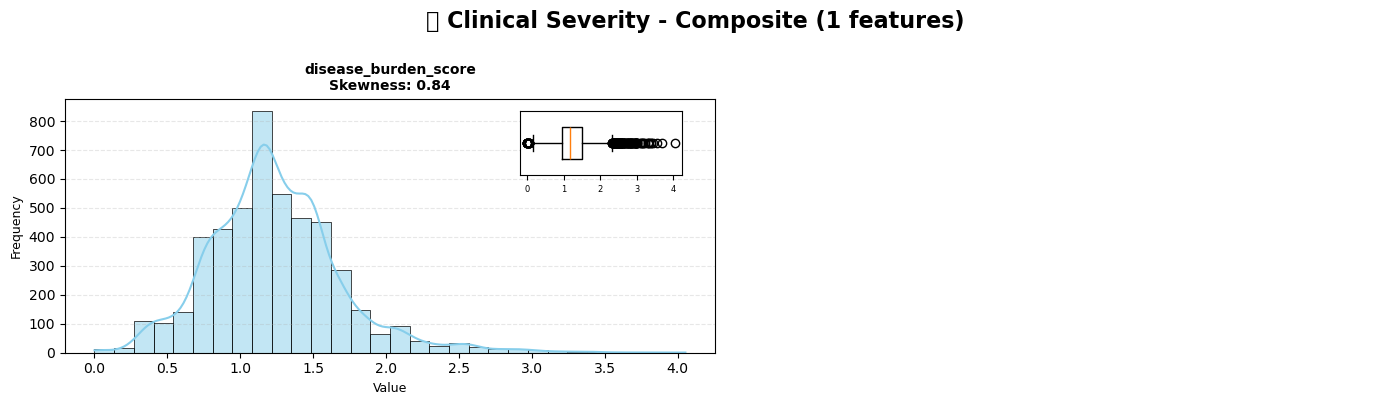


Group: Clinical Severity - Composite

disease_burden_score:
  • N values: 4761
  • Range: [0.00, 4.05]
  • Mean: 1.24 ± 0.45
  • Median: 1.18
  • Skewness: 0.84
  • % NaN: 0.0%




/tmp/ipykernel_49745/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


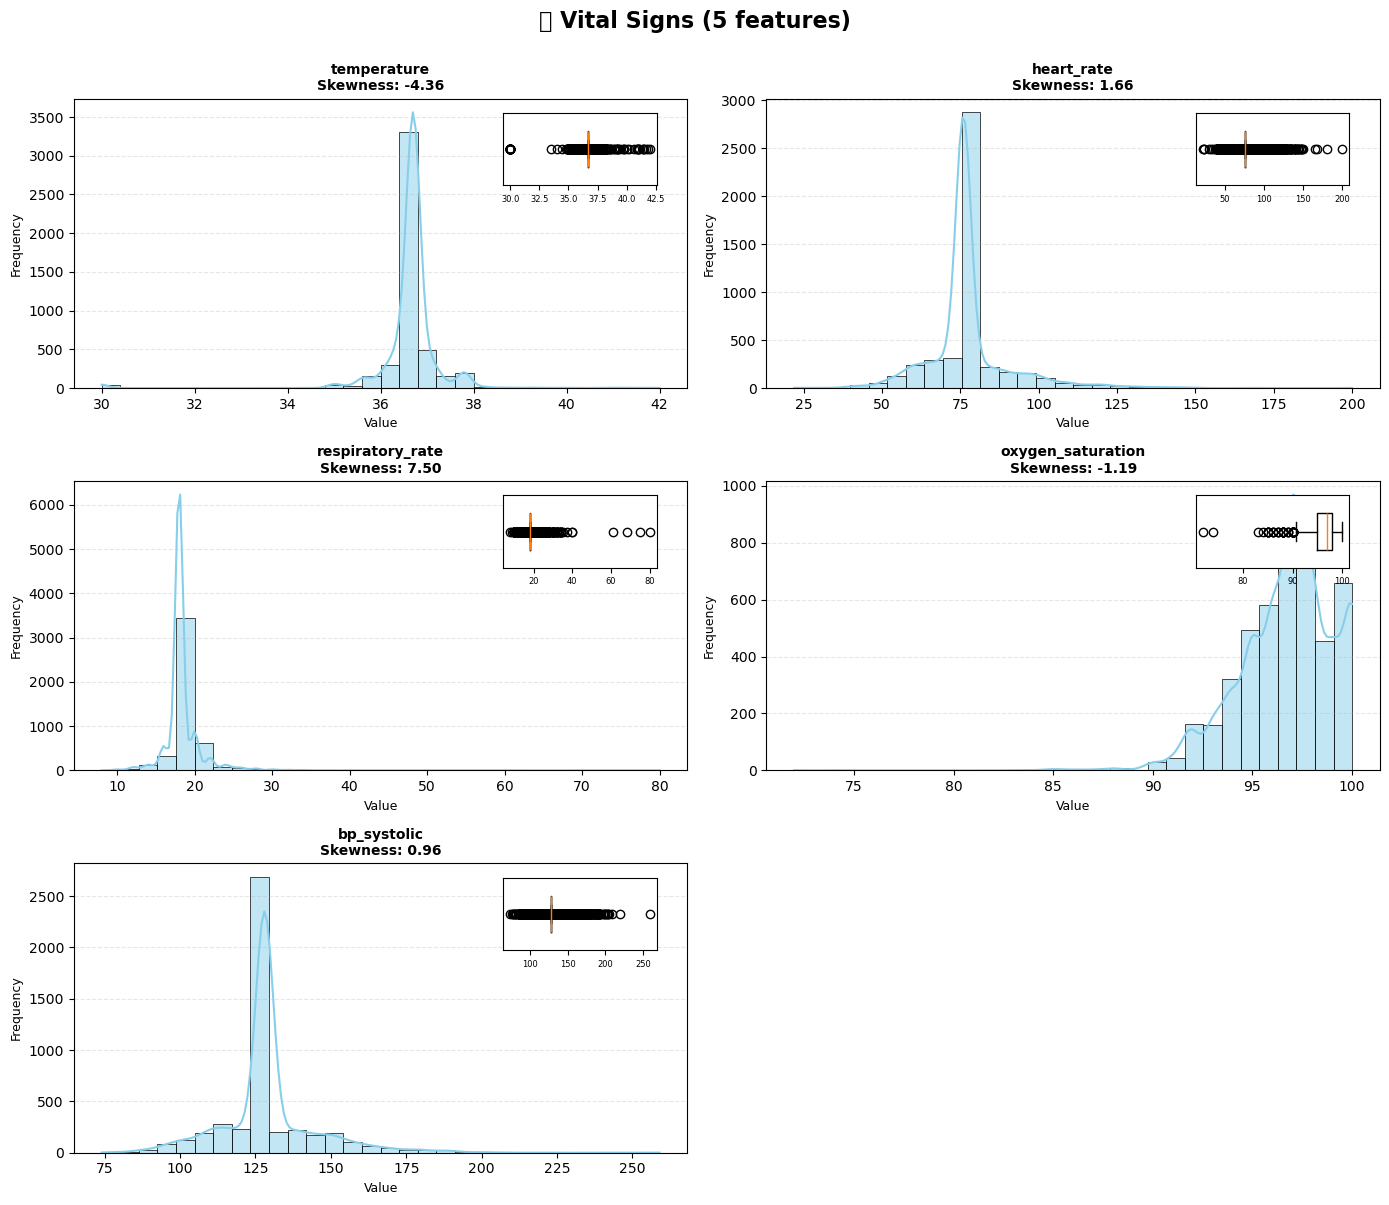


Group: Vital Signs

temperature:
  • N values: 4761
  • Range: [30.00, 42.00]
  • Mean: 36.64 ± 0.78
  • Median: 36.70
  • Skewness: -4.36
  • % NaN: 0.0%

heart_rate:
  • N values: 4761
  • Range: [22.00, 200.00]
  • Mean: 77.33 ± 13.10
  • Median: 76.00
  • Skewness: 1.66
  • % NaN: 0.0%

respiratory_rate:
  • N values: 4761
  • Range: [8.00, 80.00]
  • Mean: 18.44 ± 2.75
  • Median: 18.00
  • Skewness: 7.50
  • % NaN: 0.0%

oxygen_saturation:
  • N values: 4761
  • Range: [72.00, 100.00]
  • Mean: 96.75 ± 2.40
  • Median: 97.00
  • Skewness: -1.19
  • % NaN: 0.0%

bp_systolic:
  • N values: 4761
  • Range: [74.00, 259.00]
  • Mean: 129.11 ± 15.57
  • Median: 128.00
  • Skewness: 0.96
  • % NaN: 0.0%




/tmp/ipykernel_49745/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


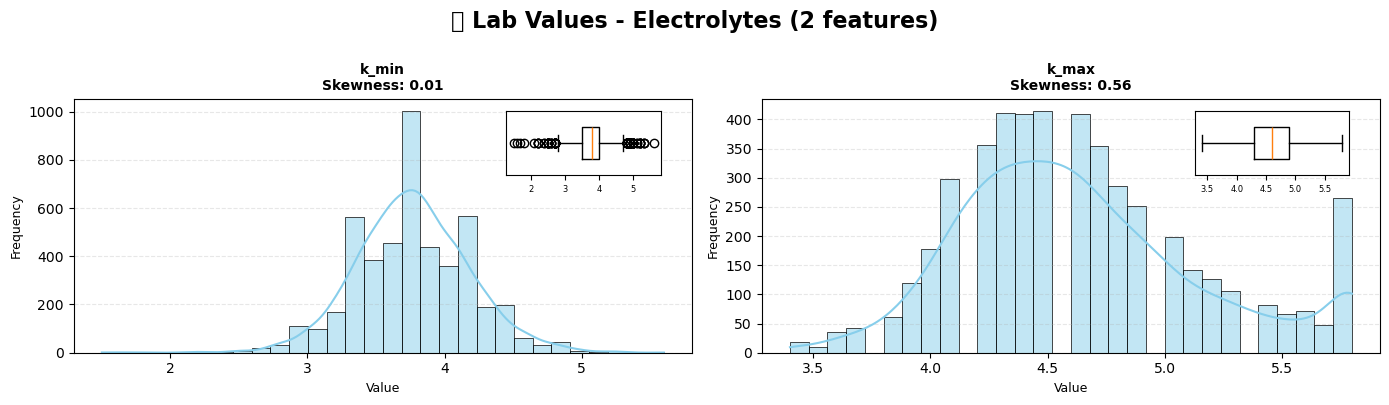


Group: Lab Values - Electrolytes

k_min:
  • N values: 4761
  • Range: [1.50, 5.60]
  • Mean: 3.77 ± 0.41
  • Median: 3.80
  • Skewness: 0.01
  • % NaN: 0.0%

k_max:
  • N values: 4761
  • Range: [3.40, 5.80]
  • Mean: 4.63 ± 0.52
  • Median: 4.60
  • Skewness: 0.56
  • % NaN: 0.0%




/tmp/ipykernel_49745/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


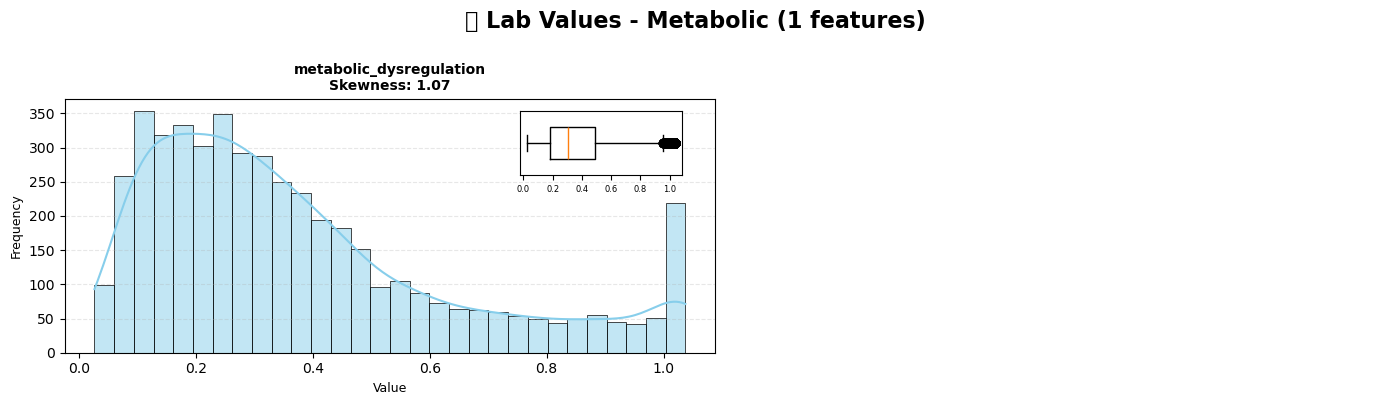


Group: Lab Values - Metabolic

metabolic_dysregulation:
  • N values: 4761
  • Range: [0.03, 1.04]
  • Mean: 0.38 ± 0.26
  • Median: 0.31
  • Skewness: 1.07
  • % NaN: 0.0%




/tmp/ipykernel_49745/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


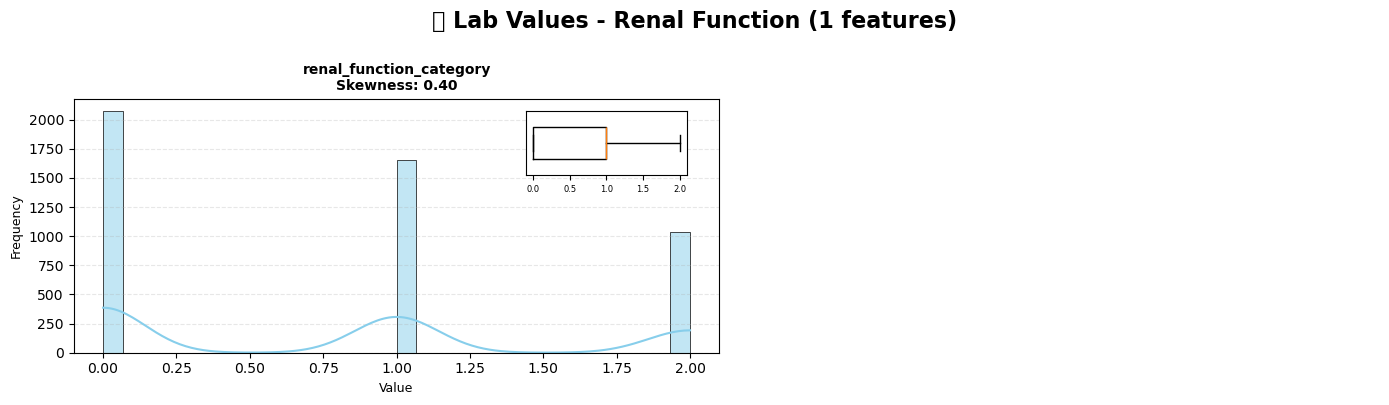


Group: Lab Values - Renal Function

renal_function_category:
  • N values: 4761
  • Range: [0.00, 2.00]
  • Mean: 0.78 ± 0.78
  • Median: 1.00
  • Skewness: 0.40
  • % NaN: 0.0%




/tmp/ipykernel_49745/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


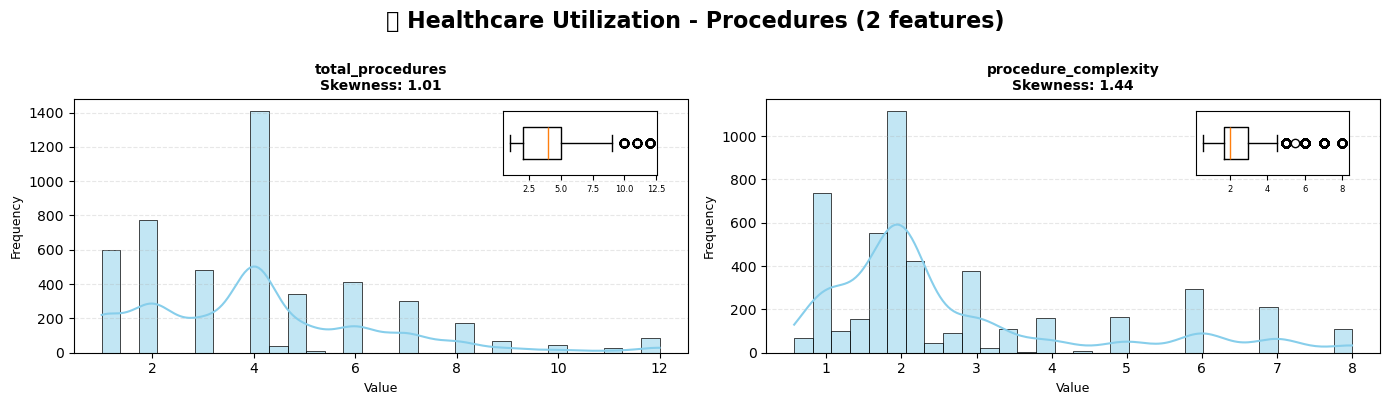


Group: Healthcare Utilization - Procedures

total_procedures:
  • N values: 4761
  • Range: [1.00, 12.00]
  • Mean: 4.09 ± 2.35
  • Median: 4.00
  • Skewness: 1.01
  • % NaN: 0.0%

procedure_complexity:
  • N values: 4761
  • Range: [0.57, 8.00]
  • Mean: 2.69 ± 1.81
  • Median: 2.00
  • Skewness: 1.44
  • % NaN: 0.0%




/tmp/ipykernel_49745/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


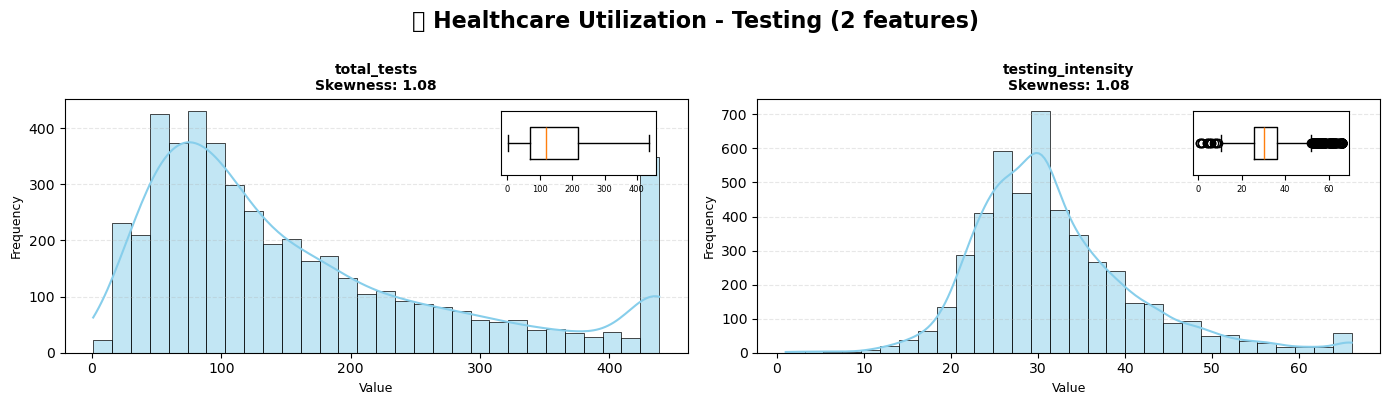


Group: Healthcare Utilization - Testing

total_tests:
  • N values: 4761
  • Range: [1.00, 438.50]
  • Mean: 159.67 ± 118.96
  • Median: 118.00
  • Skewness: 1.08
  • % NaN: 0.0%

testing_intensity:
  • N values: 4761
  • Range: [1.00, 66.10]
  • Mean: 31.89 ± 9.44
  • Median: 30.24
  • Skewness: 1.08
  • % NaN: 0.0%




/tmp/ipykernel_49745/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


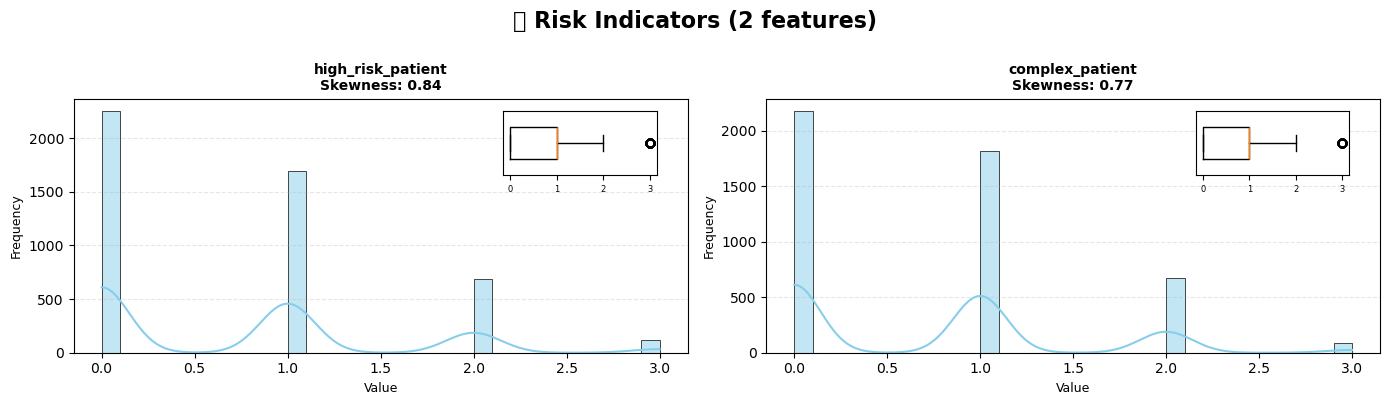


Group: Risk Indicators

high_risk_patient:
  • N values: 4761
  • Range: [0.00, 3.00]
  • Mean: 0.72 ± 0.80
  • Median: 1.00
  • Skewness: 0.84
  • % NaN: 0.0%

complex_patient:
  • N values: 4761
  • Range: [0.00, 3.00]
  • Mean: 0.72 ± 0.77
  • Median: 1.00
  • Skewness: 0.77
  • % NaN: 0.0%




/tmp/ipykernel_49745/515726874.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


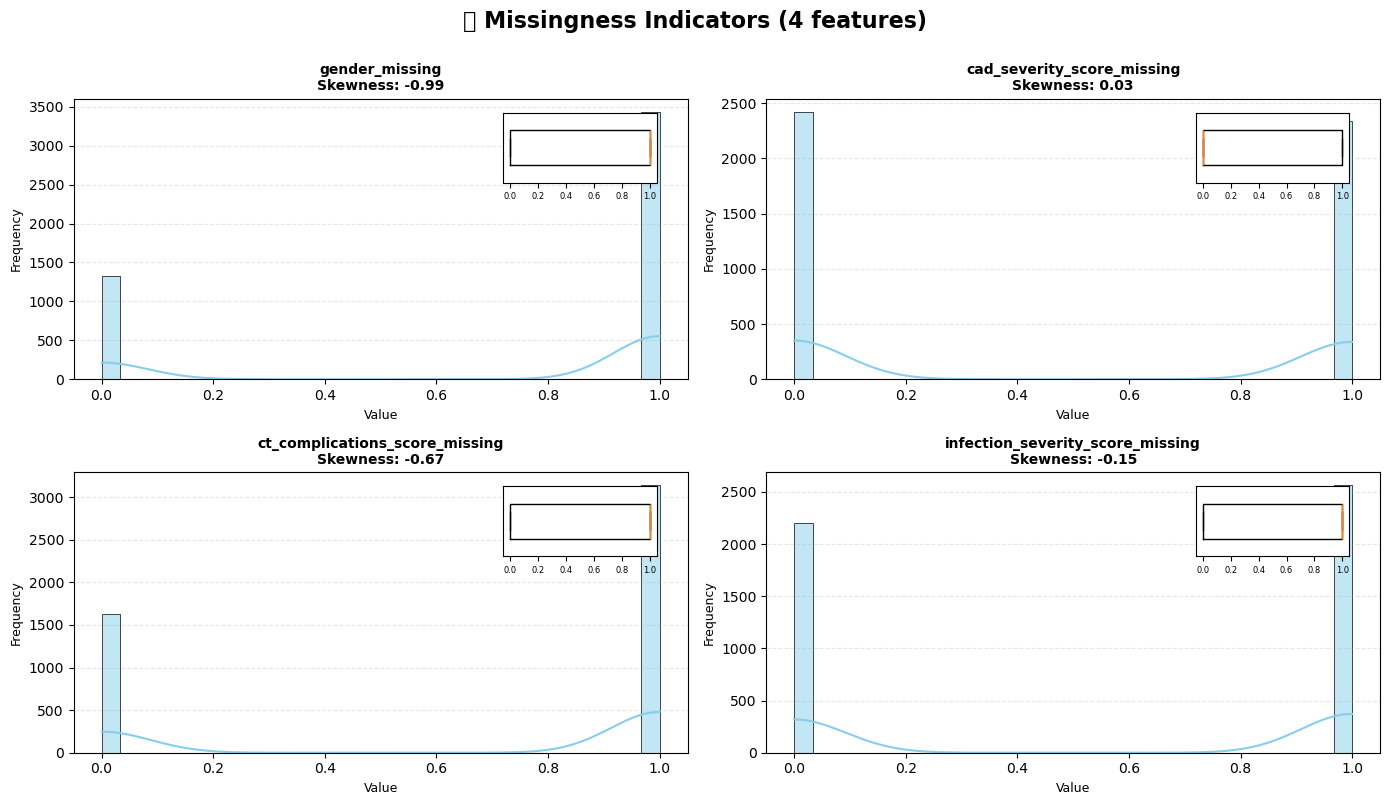


Group: Missingness Indicators

gender_missing:
  • N values: 4761
  • Range: [0.00, 1.00]
  • Mean: 0.72 ± 0.45
  • Median: 1.00
  • Skewness: -0.99
  • % NaN: 0.0%

cad_severity_score_missing:
  • N values: 4761
  • Range: [0.00, 1.00]
  • Mean: 0.49 ± 0.50
  • Median: 0.00
  • Skewness: 0.03
  • % NaN: 0.0%

ct_complications_score_missing:
  • N values: 4761
  • Range: [0.00, 1.00]
  • Mean: 0.66 ± 0.47
  • Median: 1.00
  • Skewness: -0.67
  • % NaN: 0.0%

infection_severity_score_missing:
  • N values: 4761
  • Range: [0.00, 1.00]
  • Mean: 0.54 ± 0.50
  • Median: 1.00
  • Skewness: -0.15
  • % NaN: 0.0%




In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

for group_name, features in feature_groups.items():
    existing_features = [f for f in features if f in patient_profiles_clean.columns]
    
    if not existing_features:
        continue
    
    n_cols = 2
    n_rows = (len(existing_features) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()

    for i, col in enumerate(existing_features):
        ax = axes[i]
        
        data = patient_profiles_clean[col].dropna()
        
        if len(data) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{col}\n(No data)", fontsize=10)
            continue
        
        sns.histplot(data, kde=True, bins=30, ax=ax, color='skyblue', edgecolor='black', linewidth=0.5)
        
        skew_val = skew(data)
        ax_box = ax.inset_axes([0.7, 0.7, 0.25, 0.25])
        ax_box.boxplot(data, vert=False, widths=0.5)
        ax_box.set_yticks([])
        ax_box.set_xlabel('')
        ax_box.tick_params(labelsize=6)
        
        ax.set_title(f"{col}\nSkewness: {skew_val:.2f}", fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Hide unused axes
    for j in range(len(existing_features), len(axes)):
        axes[j].axis('off')
    
    # Main title
    plt.suptitle(f'📊 {group_name} ({len(existing_features)} features)', 
                 fontsize=16, fontweight='bold', y=1.00)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*80}")
    print(f"Group: {group_name}")
    print(f"{'='*80}")
    
    # Print statistics for each feature
    for col in existing_features:
        data = patient_profiles_clean[col].dropna()
        if len(data) > 0:
            print(f"\n{col}:")
            print(f"  • N values: {len(data)}")
            print(f"  • Range: [{data.min():.2f}, {data.max():.2f}]")
            print(f"  • Mean: {data.mean():.2f} ± {data.std():.2f}")
            print(f"  • Median: {data.median():.2f}")
            print(f"  • Skewness: {skew(data):.2f}")
            print(f"  • % NaN: {(patient_profiles_clean[col].isna().sum() / len(patient_profiles_clean) * 100):.1f}%")
    
    print(f"\n{'='*80}\n")


In [57]:
skewness = patient_profiles_clean.skew()
skewed_features = skewness[abs(skewness) > 1].index.tolist()

print(f"Features with skewness > 1: {len(skewed_features)}")
print("\nSkewness per feature:")
print(skewness[abs(skewness) > 1].sort_values(ascending=False))

Features with skewness > 1: 10

Skewness per feature:
respiratory_rate           7.504663
ct_complications_score     2.765916
heart_rate                 1.658918
procedure_complexity       1.439927
total_tests                1.080040
testing_intensity          1.078189
metabolic_dysregulation    1.068264
total_procedures           1.012312
oxygen_saturation         -1.192698
temperature               -4.358239
dtype: float64


In [58]:
import numpy as np
from scipy.stats import boxcox, yeojohnson
from scipy.stats import skew

def transform_skewed_feature(series, skew_value, method='auto'):
    """
    Advanced feature transformation based on skewness value and data characteristics.
    
    Rules:
    - Skew > 3: Yeo-Johnson (optimal power transformation)
    - 1.5 < Skew <= 3: Box-Cox or sqrt (depends on data range)
    - 1 < Skew <= 1.5: Square root (gentle transformation)
    - |Skew| <= 1: No transformation
    - Skew < -1: Reflect + appropriate transformation
    
    Parameters:
    -----------
    series : pd.Series
        The feature to transform
    skew_value : float
        The skewness value
    method : str
        'auto' (default), 'boxcox', 'yeojohnson', 'sqrt', 'log'
    
    Returns:
    --------
    transformed : pd.Series
        The transformed series
    transformation_name : str
        Description of the transformation applied
    """
    
    transformed = series.copy()
    non_null_mask = transformed.notna()
    non_null_data = transformed[non_null_mask]
    
    if len(non_null_data) == 0:
        return transformed, 'no_transform (all NaN)'
    
    # Calculate data characteristics
    data_min = non_null_data.min()
    data_max = non_null_data.max()
    data_range = data_max - data_min
    has_zeros = (non_null_data == 0).any()
    has_negatives = (non_null_data < 0).any()
    
    
    if skew_value > 1:
        if skew_value > 3 or method == 'yeojohnson':
            try:
                transformed_data, lambda_param = yeojohnson(non_null_data)
                transformed[non_null_mask] = transformed_data
                return transformed, f'yeojohnson (λ={lambda_param:.3f})'
            except:
                pass  # Fallback to next method
        
        if 1.5 < skew_value <= 3:
            if data_max < 100 or method == 'boxcox':
                try:
                    # Handle zeros and negatives for Box-Cox
                    if has_negatives or has_zeros:
                        shift = abs(data_min) + 1
                        data_shifted = non_null_data + shift
                        transformed_data, lambda_param = boxcox(data_shifted)
                        transformed[non_null_mask] = transformed_data
                        return transformed, f'boxcox (λ={lambda_param:.3f}, shift={shift:.2f})'
                    else:
                        transformed_data, lambda_param = boxcox(non_null_data)
                        transformed[non_null_mask] = transformed_data
                        return transformed, f'boxcox (λ={lambda_param:.3f})'
                except:
                    # Fallback to sqrt
                    if has_negatives:
                        shift = abs(data_min) + 1
                        transformed[non_null_mask] = np.sqrt(non_null_data + shift)
                        return transformed, f'sqrt (shifted by {shift:.2f})'
                    else:
                        transformed[non_null_mask] = np.sqrt(non_null_data)
                        return transformed, 'sqrt'
        
        if 1 < skew_value <= 1.5 or method == 'sqrt':
            if has_negatives:
                shift = abs(data_min) + 1
                transformed[non_null_mask] = np.sqrt(non_null_data + shift)
                return transformed, f'sqrt (shifted by {shift:.2f})'
            else:
                transformed[non_null_mask] = np.sqrt(non_null_data)
                return transformed, 'sqrt'
        
        if has_negatives:
            shift = abs(data_min) + 1
            transformed[non_null_mask] = np.log1p(non_null_data + shift)
            return transformed, f'log1p (shifted by {shift:.2f})'
        else:
            transformed[non_null_mask] = np.log1p(non_null_data)
            return transformed, 'log1p'
    
    elif skew_value < -1:
        # Reflect the data
        max_val = non_null_data.max()
        reflected = max_val - non_null_data
        if abs(skew_value) > 3:
            try:
                transformed_data, _ = yeojohnson(reflected)
                transformed[non_null_mask] = transformed_data
                return transformed, 'reflect + yeojohnson'
            except:
                pass
        
        if abs(skew_value) > 1.5:
            transformed[non_null_mask] = np.sqrt(reflected + 1)
            return transformed, 'reflect + sqrt'
        else:
            transformed[non_null_mask] = np.log1p(reflected)
            return transformed, 'reflect + log1p'
    
    else:
        return transformed, 'no_transform (skewness acceptable)'



def transform_all_skewed_features(df, skew_threshold=1.0, exclude_cols=None, method='auto'):
    """
    Apply appropriate transformations to all skewed features in a dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe with features
    skew_threshold : float
        Minimum skewness to trigger transformation (default: 1.0)
    exclude_cols : list
        Columns to exclude from transformation
    method : str
        Transformation method: 'auto', 'boxcox', 'yeojohnson', 'sqrt', 'log'
    
    Returns:
    --------
    df_transformed : pd.DataFrame
        Dataframe with transformed features
    transformation_info : dict
        Information about transformations applied
    """
    
    if exclude_cols is None:
        exclude_cols = []
    
    df_transformed = df.copy()
    transformation_info = {}
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    for col in numeric_cols:
        data = df[col].dropna()
        
        if len(data) == 0:
            continue
        
        original_skew = skew(data)
        
        if abs(original_skew) > skew_threshold:
            # Apply transformation
            transformed_col, transform_name = transform_skewed_feature(
                df[col], 
                original_skew,
                method=method
            )
            
            # Calculate new skewness
            new_skew = skew(transformed_col.dropna())
            improvement = abs(original_skew) - abs(new_skew)
            
            # Update dataframe
            df_transformed[col] = transformed_col
            
            # Store info
            transformation_info[col] = {
                'method': transform_name,
                'original_skew': original_skew,
                'new_skew': new_skew,
                'improvement': improvement
            }
    
    return df_transformed, transformation_info


In [59]:
df_transformed, info = transform_all_skewed_features(
    patient_profiles_clean,
    skew_threshold=1.0,
    exclude_cols=['subject_id'],
    method='auto'
)

In [60]:
for col, details in info.items():
    print(f"{col}: {details['method']} → improvement: {details['improvement']:.2f}")

heart_rate: log1p → improvement: 1.64
testing_intensity: sqrt → improvement: 0.68
respiratory_rate: yeojohnson (λ=-0.770) → improvement: 7.14
oxygen_saturation: reflect + log1p → improvement: 0.55
procedure_complexity: sqrt → improvement: 0.47
temperature: reflect + yeojohnson → improvement: 3.77
total_tests: sqrt → improvement: 0.55
total_procedures: sqrt → improvement: 0.78
ct_complications_score: boxcox (λ=-0.335, shift=1.00) → improvement: 2.72
metabolic_dysregulation: sqrt → improvement: 0.59


We conclude the patient profile creation report by proving that the dataset created is good for clustering by Hopkins score  

In [61]:
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform
from math import isnan

def hopkins_statistic(X):
    X = X.values  # convert to numpy array
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n) 
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
 
    rand_X = sample(range(0, n, 1), m)
 
    ujd = []
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X[rand_X[j]].reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
 
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0
 
    return H

print(f"Hopkins Statistic: {hopkins_statistic(df_transformed)}")


Hopkins Statistic: 0.8291407794512788


In [62]:
# Save the processed dataset
output_path = 'patient_profiles.csv'
df_transformed.to_csv(Path().resolve().parent / 'Features' / output_path, index=False)